# IEEE-CIS Fraud Detection — Exploratory Data Analysis

**Author:** Ganbold  
**Date:** April 2026  
**Dataset:** [IEEE-CIS Fraud Detection](https://www.kaggle.com/competitions/ieee-fraud-detection) (Kaggle)  

---

## Objective

This notebook explores the IEEE-CIS fraud detection dataset to understand the structure of the data, identify patterns that distinguish fraudulent from legitimate transactions, and surface insights that will guide feature engineering and modelling decisions.

The dataset contains real-world ecommerce transactions from Vesta Corporation with over 400 features covering transaction details, card information, device data, and behavioural signals.

---

## Table of Contents

1. [Setup & Data Loading](#1-setup--data-loading)
2. [Dataset Overview](#2-dataset-overview)
3. [Fraud Rate & Class Imbalance](#3-fraud-rate--class-imbalance)
4. [Transaction Amounts](#4-transaction-amounts)
5. [Fraud Over Time](#5-fraud-over-time)
6. [Product Type Analysis](#6-product-type-analysis)
7. [Card Network Analysis](#7-card-network-analysis)
8. [Missing Values](#8-missing-values)
9. [Key Findings Summary](#9-key-findings-summary)

## 1. Setup & Data Loading

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
pd.set_option('display.max_columns', 100)

# Create charts directory if it doesn't exist
os.makedirs('charts', exist_ok=True)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [8]:
# --- Flexible path: works on any machine ---
# Looks for data/ relative to where this notebook lives
NOTEBOOK_DIR = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(NOTEBOOK_DIR, '..', 'data')

train_transaction = pd.read_csv(os.path.join(DATA_DIR, r'C:\Users\ganbo\ieee-fraud-detection\data\train_transaction.csv'))
train_identity    = pd.read_csv(os.path.join(DATA_DIR, r'C:\Users\ganbo\ieee-fraud-detection\data\train_identity.csv'))

df = train_transaction.merge(train_identity, on='TransactionID', how='left')

print(f"Transactions loaded: {len(df):,}")
print(f"Features:            {df.shape[1]}")
print(f"Transaction file:    {train_transaction.shape}")
print(f"Identity file:       {train_identity.shape}  (not all transactions have identity info)")

Transactions loaded: 590,540
Features:            434
Transaction file:    (590540, 394)
Identity file:       (144233, 41)  (not all transactions have identity info)


## 2. Dataset Overview

Before diving into charts, it's important to understand what we're working with — how many rows, what types of columns, and where the missing values are.

In [9]:
print("── Shape ──────────────────────────────────────")
print(f"  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")

print("\n── Column Data Types ──────────────────────────")
print(df.dtypes.value_counts().to_string())

print("\n── Target Variable Distribution ───────────────")
vc = df['isFraud'].value_counts()
print(f"  Legitimate (0): {vc[0]:>8,}")
print(f"  Fraud      (1): {vc[1]:>8,}")

print("\n── Sample Transactions ────────────────────────")
df[['TransactionID', 'TransactionAmt', 'ProductCD', 'card4', 'card6', 'isFraud']].head(5)

── Shape ──────────────────────────────────────
  Rows: 590,540  |  Columns: 434

── Column Data Types ──────────────────────────
float64    399
object      31
int64        4

── Target Variable Distribution ───────────────
  Legitimate (0):  569,877
  Fraud      (1):   20,663

── Sample Transactions ────────────────────────


,TransactionID,TransactionAmt,ProductCD,card4,card6,isFraud
0,2987000,68.5,W,discover,credit,0
1,2987001,29.0,W,mastercard,credit,0
2,2987002,59.0,W,visa,debit,0
3,2987003,50.0,W,mastercard,debit,0
4,2987004,50.0,H,mastercard,credit,0


> **Note:** The dataset has two file types joined on `TransactionID`. The transaction file contains payment and behavioural features; the identity file has device and network info. Not every transaction has an identity record — this explains the high missing rate in `id_*` columns.

## 3. Fraud Rate & Class Imbalance

The first thing a fraud analyst checks: how rare is fraud in the data? This matters because a model that predicts "not fraud" every time would look highly accurate on paper but would be completely useless in practice.

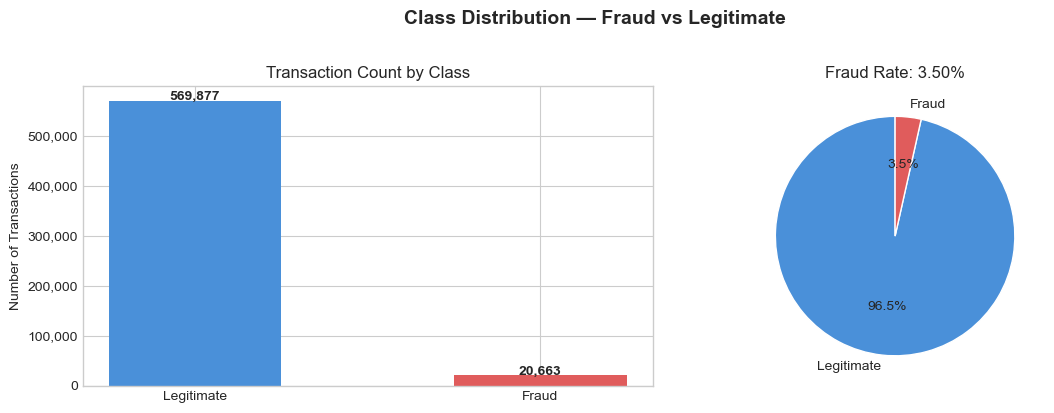

Fraud rate: 3.50%
A naive model predicting 'not fraud' every time would be 96.5% accurate — but useless.


In [12]:
fraud_counts = df['isFraud'].value_counts()
fraud_rate   = df['isFraud'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(
    ['Legitimate', 'Fraud'],
    fraud_counts.values,
    color=['#4a90d9', '#e05c5c'],
    width=0.5
)
axes[0].set_title('Transaction Count by Class', fontsize=12)
axes[0].set_ylabel('Number of Transactions')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for bar, val in zip(bars, fraud_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(
    fraud_counts.values,
    labels=['Legitimate', 'Fraud'],
    colors=['#4a90d9', '#e05c5c'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
)
axes[1].set_title(f'Fraud Rate: {fraud_rate:.2f}%', fontsize=12)

plt.suptitle('Class Distribution — Fraud vs Legitimate', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fraud rate: {fraud_rate:.2f}%")
print(f"A naive model predicting 'not fraud' every time would be {100 - fraud_rate:.1f}% accurate — but useless.")

> **Insight:** Only **3.5%** of transactions are fraudulent, creating a significant class imbalance. Standard accuracy is a misleading metric here — we'll use **ROC-AUC** instead, which measures how well the model separates fraud from legitimate transactions regardless of the imbalance. In notebook 03, we handle this using `scale_pos_weight` in XGBoost.

## 4. Transaction Amounts

Do fraudulent transactions tend to be for different amounts than legitimate ones? This is one of the first signals a fraud analyst would check — fraudsters often avoid very large amounts to dodge manual review thresholds.

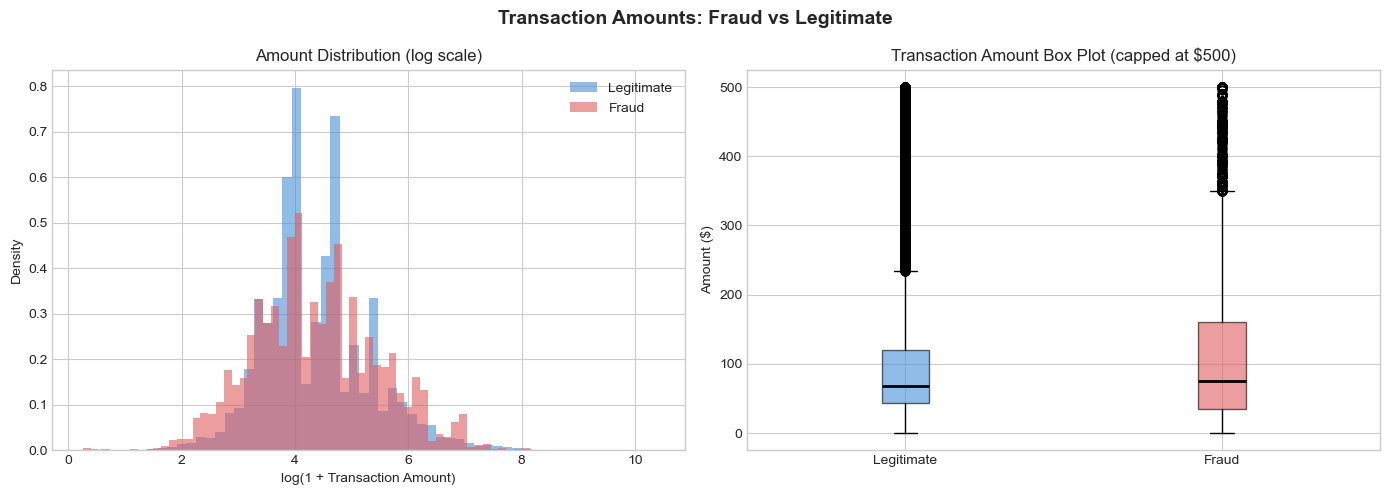

Median legitimate transaction: $68.50
Median fraudulent transaction: $75.00
Mean   legitimate transaction: $134.51
Mean   fraudulent transaction: $149.24


In [14]:
fraud_amt = df[df['isFraud'] == 1]['TransactionAmt']
legit_amt = df[df['isFraud'] == 0]['TransactionAmt']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlapping distributions on log scale
axes[0].hist(np.log1p(legit_amt), bins=60, alpha=0.6, color='#4a90d9', label='Legitimate', density=True)
axes[0].hist(np.log1p(fraud_amt), bins=60, alpha=0.6, color='#e05c5c', label='Fraud', density=True)
axes[0].set_title('Amount Distribution (log scale)', fontsize=12)
axes[0].set_xlabel('log(1 + Transaction Amount)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box plot (capped for readability)
bp = axes[1].boxplot(
    [legit_amt.clip(upper=500), fraud_amt.clip(upper=500)],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor('#4a90d9')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#e05c5c')
bp['boxes'][1].set_alpha(0.6)
axes[1].set_title('Transaction Amount Box Plot (capped at $500)', fontsize=12)
axes[1].set_ylabel('Amount ($)')

plt.suptitle('Transaction Amounts: Fraud vs Legitimate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/02_amounts.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median legitimate transaction: ${legit_amt.median():.2f}")
print(f"Median fraudulent transaction: ${fraud_amt.median():.2f}")
print(f"Mean   legitimate transaction: ${legit_amt.mean():.2f}")
print(f"Mean   fraudulent transaction: ${fraud_amt.mean():.2f}")

> **Insight:** Fraudulent transactions are concentrated in a narrower amount range with a slightly higher median than legitimate ones. The distribution of legitimate transactions has a much longer tail (very large purchases), while fraud is notably absent at the very high end. This is consistent with fraudsters staying below thresholds that trigger manual review — a pattern commonly observed in ecommerce fraud.

## 5. Fraud Over Time

`TransactionDT` is a timedelta in seconds from a reference point. We can convert it to hours to find when fraud is most likely to occur — this is useful for real-time monitoring systems that want to increase scrutiny during high-risk windows.

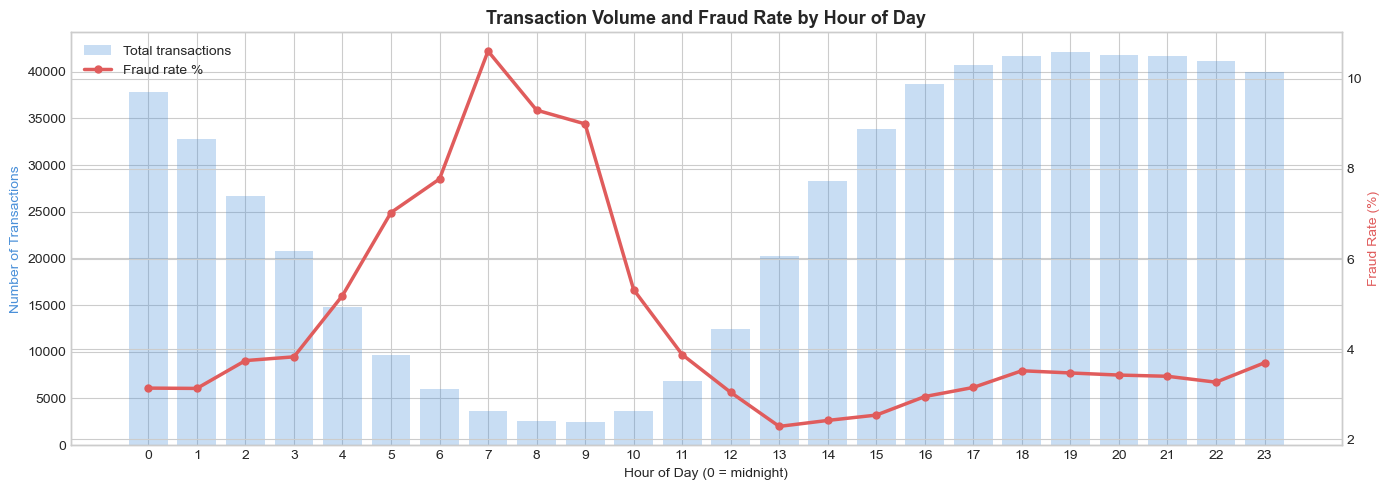

Peak fraud hour: 7:00 (10.6% fraud rate)
Lowest volume hour: 9:00


In [16]:
df['hour'] = (df['TransactionDT'] / 3600).astype(int) % 24

hourly = df.groupby('hour')['isFraud'].agg(
    fraud_rate='mean',
    fraud_count='sum',
    total='count'
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(hourly['hour'], hourly['total'], alpha=0.3, color='#4a90d9', label='Total transactions', width=0.8)
ax2.plot(hourly['hour'], hourly['fraud_rate'] * 100, color='#e05c5c',
         linewidth=2.5, marker='o', markersize=5, label='Fraud rate %')

ax1.set_xlabel('Hour of Day (0 = midnight)')
ax1.set_ylabel('Number of Transactions', color='#4a90d9')
ax2.set_ylabel('Fraud Rate (%)', color='#e05c5c')
ax1.set_xticks(range(0, 24))
ax1.set_title('Transaction Volume and Fraud Rate by Hour of Day', fontsize=13, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('charts/03_fraud_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

peak_fraud_hour = hourly.loc[hourly['fraud_rate'].idxmax(), 'hour']
peak_fraud_rate = hourly['fraud_rate'].max() * 100
print(f"Peak fraud hour: {peak_fraud_hour}:00 ({peak_fraud_rate:.1f}% fraud rate)")
print(f"Lowest volume hour: {hourly.loc[hourly['total'].idxmin(), 'hour']}:00")

> **Insight:** Fraud rate is inversely correlated with transaction volume — it spikes during low-volume hours, typically late at night, when fewer transactions are processed and human review teams are smaller. This is a common pattern in ecommerce fraud. `hour` should be engineered as a feature in the next notebook.

## 6. Product Type Analysis

The `ProductCD` column encodes the category of product purchased. Certain product types may be disproportionately targeted by fraudsters — for example, digital goods are a common fraud target because they're instantly deliverable and hard to reverse.

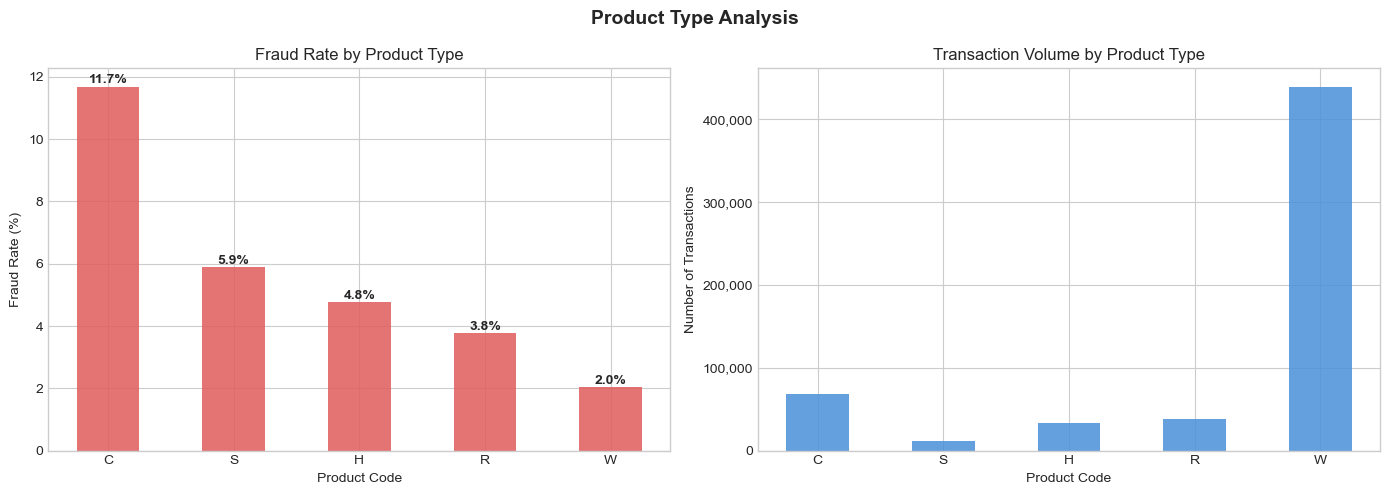

ProductCD  fraud_rate  total  fraud_count
        C       11.69  68519         8008
        S        5.90  11628          686
        H        4.77  33024         1574
        R        3.78  37699         1426
        W        2.04 439670         8969


In [18]:
product_fraud = df.groupby('ProductCD')['isFraud'].agg(
    fraud_rate='mean',
    fraud_count='sum',
    total='count'
).reset_index()
product_fraud = product_fraud.sort_values('fraud_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud rate
bars = axes[0].bar(product_fraud['ProductCD'], product_fraud['fraud_rate'] * 100,
                   color='#e05c5c', alpha=0.85, width=0.5)
axes[0].set_title('Fraud Rate by Product Type', fontsize=12)
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('Product Code')
for bar, val in zip(bars, product_fraud['fraud_rate'] * 100):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Transaction volume
axes[1].bar(product_fraud['ProductCD'], product_fraud['total'],
            color='#4a90d9', alpha=0.85, width=0.5)
axes[1].set_title('Transaction Volume by Product Type', fontsize=12)
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xlabel('Product Code')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Product Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/04_product_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

print(product_fraud[['ProductCD', 'fraud_rate', 'total', 'fraud_count']]
      .assign(fraud_rate=lambda x: (x['fraud_rate']*100).round(2))
      .to_string(index=False))

> **Insight:** Product type `C` has the highest fraud rate at ~11.7% — more than 3× the overall average. This strongly suggests `ProductCD` should be an important feature in the model. High-risk product categories could also trigger stricter real-time review rules in a production fraud system.

## 7. Card Network Analysis

The `card4` column contains the card network (Visa, Mastercard, etc.) and `card6` contains the card type (credit/debit). These are standard signals in fraud detection — certain card types carry higher risk profiles.

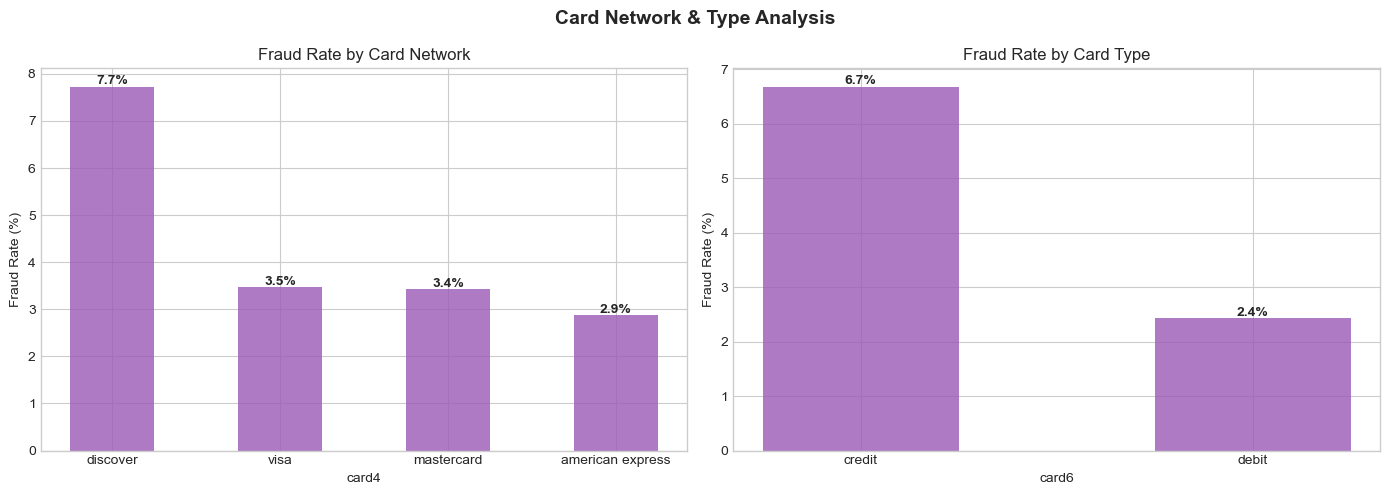

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['card4', 'card6'], ['Card Network', 'Card Type']):
    card_stats = df.groupby(col)['isFraud'].agg(
        fraud_rate='mean', total='count'
    ).reset_index().sort_values('fraud_rate', ascending=False)
    card_stats = card_stats[card_stats['total'] > 100]  # filter tiny categories

    bars = ax.bar(card_stats[col], card_stats['fraud_rate'] * 100,
                  color='#9b59b6', alpha=0.8, width=0.5)
    ax.set_title(f'Fraud Rate by {title}', fontsize=12)
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_xlabel(col)
    for bar, val in zip(bars, card_stats['fraud_rate'] * 100):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Card Network & Type Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/05_card_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insight:** There are meaningful differences in fraud rates between card networks and card types. Credit cards tend to carry higher fraud rates than debit cards — consistent with industry data, as credit card numbers are more commonly stolen and used for online fraud. These features should be included in the model.

## 8. Missing Values

With 434 features, understanding where data is missing is critical. Many `id_*` columns have >99% missing values because the identity file only covers a subset of transactions.

Columns with missing values: 414 / 435
Columns with >50% missing:   214
Columns with >90% missing:   12



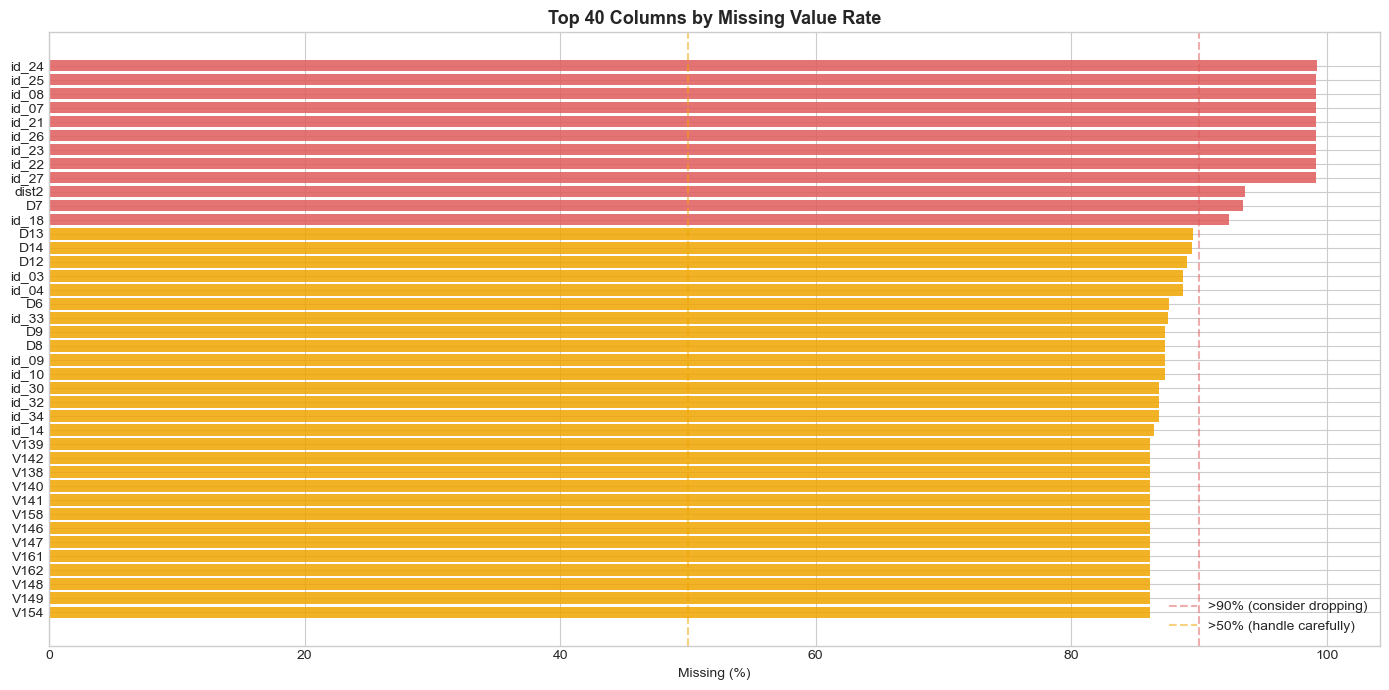

In [22]:
missing = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_cols = missing[missing > 0]

print(f"Columns with missing values: {len(missing_cols)} / {df.shape[1]}")
print(f"Columns with >50% missing:   {(missing_cols > 50).sum()}")
print(f"Columns with >90% missing:   {(missing_cols > 90).sum()}")
print()

# Visualise top 40 most-missing columns
top_missing = missing_cols.head(40)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#e05c5c' if v > 90 else '#f0a500' if v > 50 else '#4a90d9' for v in top_missing.values]
ax.barh(top_missing.index[::-1], top_missing.values[::-1], color=colors[::-1], alpha=0.85)
ax.axvline(x=90, color='#e05c5c', linestyle='--', alpha=0.5, label='>90% (consider dropping)')
ax.axvline(x=50, color='#f0a500', linestyle='--', alpha=0.5, label='>50% (handle carefully)')
ax.set_xlabel('Missing (%)')
ax.set_title('Top 40 Columns by Missing Value Rate', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('charts/06_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insight:** The majority of `id_*` columns have >99% missing data — these come from the identity file, which only covers ~40% of transactions. In preprocessing (notebook 02), we'll consider dropping columns with >90% missing values or imputing them with a sentinel value like `-999` to let the model learn from the fact that data is missing (a signal in itself).

## 9. Key Findings Summary

In [24]:
fraud_rate       = df['isFraud'].mean() * 100
fraud_count      = df['isFraud'].sum()
legit_count      = (df['isFraud'] == 0).sum()
fraud_amt        = df[df['isFraud'] == 1]['TransactionAmt']
legit_amt        = df[df['isFraud'] == 0]['TransactionAmt']
product_fraud_r  = df.groupby('ProductCD')['isFraud'].mean()
top_product      = product_fraud_r.idxmax()
top_product_rate = product_fraud_r.max() * 100
peak_hour        = hourly.loc[hourly['fraud_rate'].idxmax(), 'hour']
cols_over_90     = (missing > 90).sum()

print("=" * 60)
print(" KEY FINDINGS — EDA SUMMARY")
print("=" * 60)
print(f"  Dataset:              {len(df):,} transactions, {df.shape[1]} features")
print(f"  Fraud rate:           {fraud_rate:.2f}%  ({fraud_count:,} fraud / {legit_count:,} legitimate)")
print(f"  Median legit amount:  ${legit_amt.median():.2f}")
print(f"  Median fraud amount:  ${fraud_amt.median():.2f}")
print(f"  Highest-risk product: '{top_product}' at {top_product_rate:.1f}% fraud rate")
print(f"  Peak fraud hour:      {peak_hour}:00")
print(f"  Columns >90% missing: {cols_over_90}")
print("=" * 60)
print()
print("IMPLICATIONS FOR MODELLING (Notebook 03):")
print("  - Use ROC-AUC, not accuracy (class imbalance)")
print("  - Set scale_pos_weight in XGBoost to handle imbalance")
print("  - Engineer hour-of-day as a feature")
print("  - ProductCD and card4/card6 are likely strong predictors")
print(f"  - Drop or flag {cols_over_90} columns with >90% missing values")

 KEY FINDINGS — EDA SUMMARY
  Dataset:              590,540 transactions, 435 features
  Fraud rate:           3.50%  (20,663 fraud / 569,877 legitimate)
  Median legit amount:  $68.50
  Median fraud amount:  $75.00
  Highest-risk product: 'C' at 11.7% fraud rate
  Peak fraud hour:      7:00
  Columns >90% missing: 12

IMPLICATIONS FOR MODELLING (Notebook 03):
  - Use ROC-AUC, not accuracy (class imbalance)
  - Set scale_pos_weight in XGBoost to handle imbalance
  - Engineer hour-of-day as a feature
  - ProductCD and card4/card6 are likely strong predictors
  - Drop or flag 12 columns with >90% missing values


---

## Next Steps

➡️ **Notebook 02 — Preprocessing & Feature Engineering**  
Handle missing values, encode categorical features, and engineer new features (hour of day, log-transform amounts, card aggregations) to prepare the data for modelling.